In [64]:
import scipy as sc
import numpy as np
import sympy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from scipy.integrate import odeint, complex_ode, solve_ivp

plt.style.use(['science','notebook', 'grid'])

In [65]:
# y = np.array([ca, cb])
def dSdt(t, y):
    ca, cb = y[0], y[1]
    dca_dt = -1j * Vabh * cb * np.exp(1j * (w - w0) * t) / 2
    dcb_dt = -1j * Vabh * ca * np.exp(-1j * (w - w0) * t) / 2
    return np.array([dca_dt, dcb_dt])

In [66]:
t = np.linspace(0, 10, 1000)
w = 0.5
w0 = 1.0
Vabh = 10.0
ca0 = 1.0 + 0j; cb0 = 0.0 + 0j

sol=solve_ivp(dSdt, y0 = [ca0, cb0], t_span= (t[0], t[-1]), t_eval=t).y

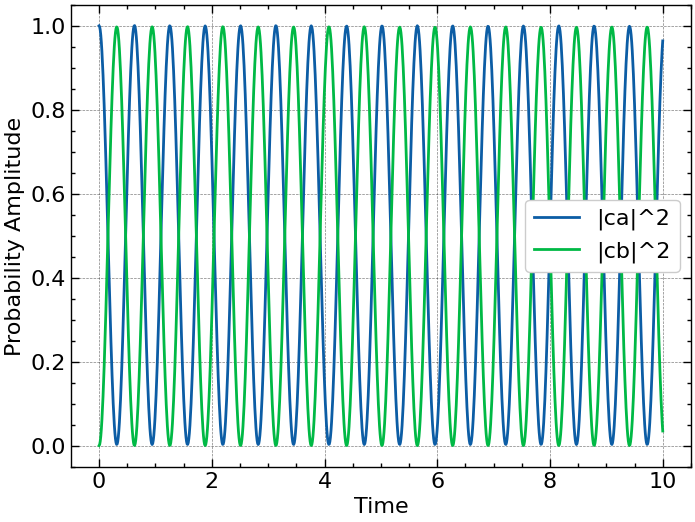

In [67]:
ca = sol[0]
cb = sol[1]

plt.plot(t, np.abs(ca)**2, label='|ca|^2')
plt.plot(t, np.abs(cb)**2, label='|cb|^2')
plt.xlabel('Time')
plt.ylabel('Probability Amplitude')
plt.legend()

In [68]:
t = np.linspace(0, 50, 1000)
wa = np.linspace(0, 4, 1000)
w0 = 1.0
Vabh = 1.0
ca0 = 1.0 + 0j; cb0 = 0.0 + 0j
caw  =[]; cbw = []
for w in wa:
    sol=solve_ivp(dSdt, y0 = [ca0, cb0], t_span= (t[0], t[-1]), t_eval=t).y
    ca = sol[0]
    cb = sol[1]
    caw.append(ca)
    cbw.append(cb)

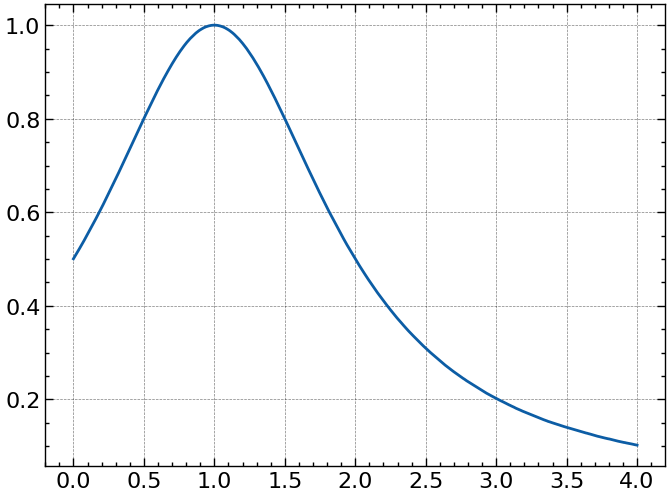

In [69]:
caw = np.array(caw); cbw = np.array(cbw)
cbmaxw = np.max(np.abs(cbw)**2, axis=1)
plt.plot(wa, cbmaxw, label='Max |cb|^2')

Text(0.5, 1.0, 'Time-Frequency Representation of |cb|^2')

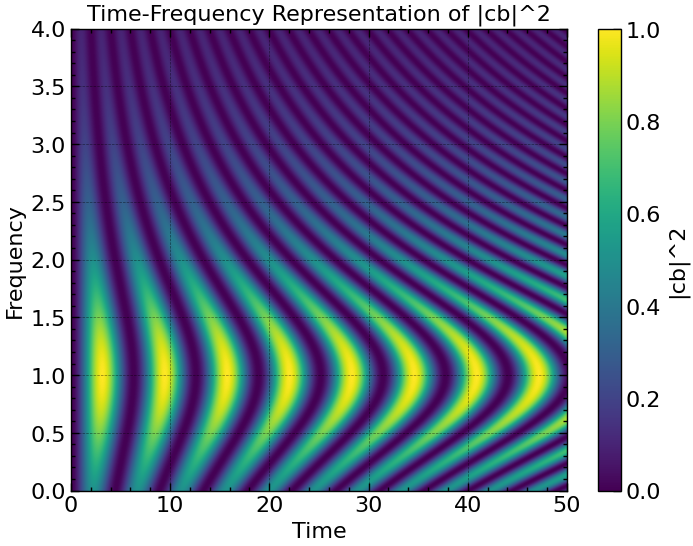

In [70]:
plt.imshow(np.abs(cbw)**2, aspect='auto', extent=[t[0], t[-1], wa[0], wa[-1]], origin='lower')
plt.colorbar(label='|cb|^2')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Time-Frequency Representation of |cb|^2' )

In [62]:
W, T = np.meshgrid(wa, t)

wr = 1/2 * np.sqrt(1 + (W - w0)**2)
A = np.sqrt(1 / (1 + ((W - w0)/Vabh)**2))

cbw = A * np.exp(-1j * (W - w0) * T / 2) * np.sin(wr * T)

Text(0.5, 1.0, 'Time-Frequency Representation of |ca|^2')

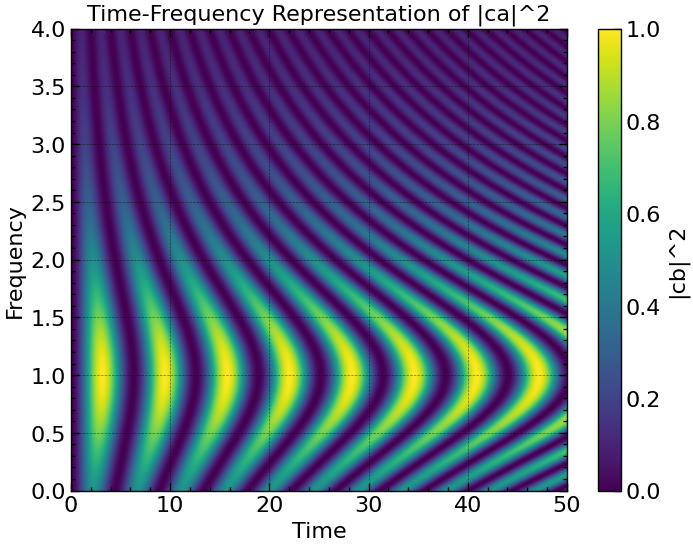

In [ ]:
plt.imshow(np.abs(cbw.T)**2, aspect='auto', extent=[t[0], t[-1], wa[0], wa[-1]], origin='lower',vmax=1)
plt.colorbar(label='|cb|^2')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Time-Frequency Representation of |ca|^2' )

In [18]:
np.shape(cbw), np.shape(T), np.shape(W)

((100, 1000), (1000, 100), (1000, 100))